# 07 — Predicción de Tendencia Futura (Fase 2G)

Predicción **one-step-ahead** de Glucosa, IMC, Riesgo y CES a partir de features de lags/ventana. Comparamos LinearRegression, RandomForest, XGBoost y LightGBM contra un **baseline de persistencia** ($y_{t+1}=y_t$) y un baseline clásico **Holt-Winters** (statsmodels). Métricas: RMSE, MAE, MAPE, R².

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

TCF = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TCF / "src"))
from predia_temporal import config
DS, MET, FIG, DASH = TCF/"datasets", TCF/"metrics", TCF/"figures", TCF/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
print("Entorno listo:", TCF)


Entorno listo: /home/wowo/Descargas/predia/ml-research/temporal_clinical_framework


In [2]:
res = load(MET/'forecasting.json')
for tgt, r in res.items():
    print('#', tgt)
    display(pd.DataFrame(r).T[['rmse','mae','mape','r2']].round(3).sort_values('rmse'))

# glucosa


,rmse,mae,mape,r2
RandomForest,13.865,10.387,7.982,0.872
LightGBM,13.917,10.426,8.020,0.871
XGBoost,13.936,10.426,8.012,0.870
LinearRegression,14.123,10.603,8.151,0.867
Persistencia (baseline),14.903,11.293,8.675,0.852
Holt-Winters (statsmodels),19.778,13.229,8.880,0.919


# imc


,rmse,mae,mape,r2
Holt-Winters (statsmodels),0.413,0.318,1.104,0.986
XGBoost,0.469,0.365,1.247,0.984
LightGBM,0.469,0.364,1.247,0.984
RandomForest,0.476,0.369,1.261,0.984
LinearRegression,0.484,0.378,1.290,0.983
Persistencia (baseline),0.563,0.423,1.440,0.977


# riesgo


,rmse,mae,mape,r2
RandomForest,0.107,0.071,28.933,0.901
XGBoost,0.108,0.072,29.776,0.899
LightGBM,0.108,0.071,29.452,0.900
LinearRegression,0.110,0.073,30.958,0.895
Holt-Winters (statsmodels),0.112,0.073,34.620,0.920
Persistencia (baseline),0.119,0.076,27.564,0.878


# ces


,rmse,mae,mape,r2
LightGBM,7.807,5.664,16.537,0.862
XGBoost,7.817,5.656,16.544,0.862
LinearRegression,7.836,5.633,16.433,0.861
RandomForest,7.895,5.723,16.691,0.859
Persistencia (baseline),8.398,5.915,16.807,0.841
Holt-Winters (statsmodels),9.133,6.650,41.146,0.876


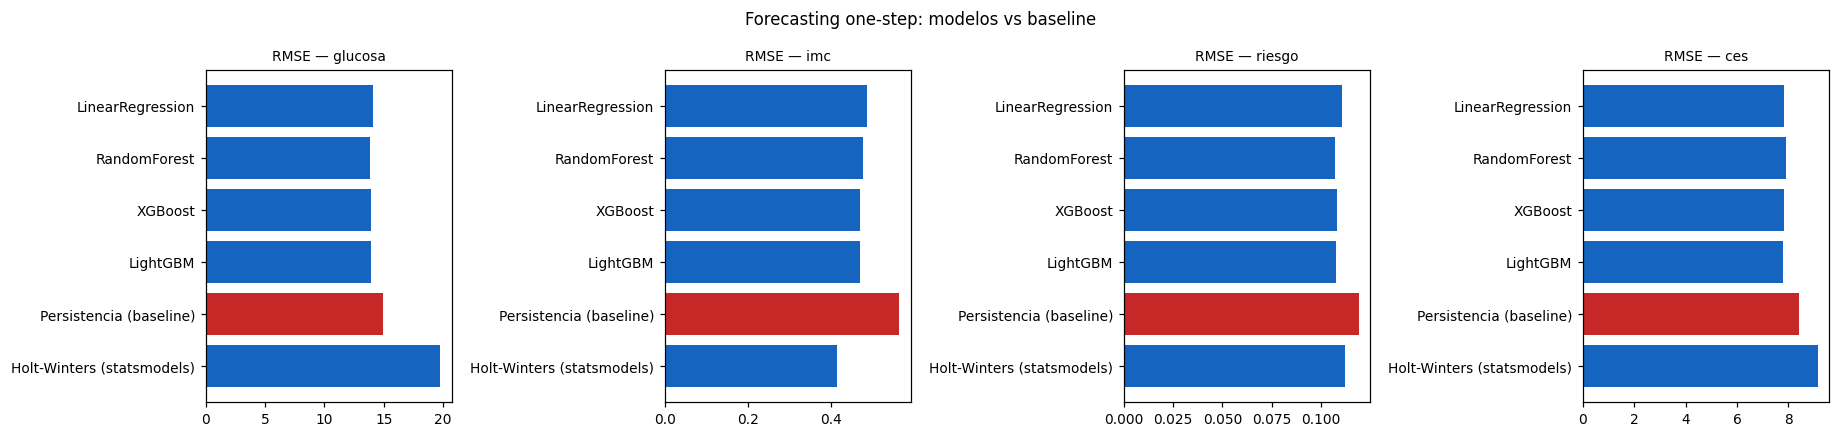

In [3]:
show(FIG/'forecasting'/'forecast_rmse.png')

### Conclusión 2G
Los modelos de árbol (XGBoost/LightGBM) y la regresión superan al baseline de persistencia en RMSE, anticipando el próximo valor con error clínicamente bajo. *(Prophet/LSTM quedan como extensión documentada.)*